# Regular 1

| | |
|---|---|
| Thời gian | 90 phút |
| Hình thức | Làm trực tiếp trên notebook này. Không xóa đề. |

### Rules
1. Import các thư viện đã học.
2. Mọi nhận xét viết ngắn gọn, dựa trên kết quả vừa tính — không copy insight có sẵn.
3. Chạy cell theo thứ tự từ trên xuống.
4. Biểu đồ phải có title và nhãn trục. In kết quả số ra màn hình.

### Bảng điểm tóm tắt

| Phần | Nội dung | Điểm |
|---|---|---|
| 0 | Import, load | không tính điểm |
| 1 | Inspection | 2,5 |
| 2 | Data cleaning (missing, dtype, feature) | 3,5 |
| 3 | EDA (Univariate & Multivariate) | 3,0 |
| 4 | Summary & insights | 1,0 |
| **Tổng** | | **10,0** |
| Bonus | | +2,0 |
| **Tối đa** | | **12,0** |


# Import thư viện


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset Description

Cột gốc (file CSV):

- show_id: mã từng title
- type: Movie hoặc TV Show
- title: tên phim hoặc chương trình
- director: đạo diễn
- cast: diễn viên
- country: quốc gia sản xuất; 
- date_added: ngày thêm 
- release_year: năm phát hành gốc
- rating: xếp hạng độ tuổi
- duration: thời lượng dạng chữ. Movie là phút (90 min), TV Show là số mùa (2 Seasons)
- listed_in: thể loại; có thể nhiều tag
- description: tóm tắt nội dung


# Load data

Đọc file data.csv vào df.


In [2]:
df = pd.read_csv('data.csv')

# Phần 1 — Inspection (**2,5 đ**)

Khám phá dữ liệu gốc df trước khi clean.


### Câu 1.1 — In 10 dòng đầu (**0,1 đ**)


In [3]:
# Your code here
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


### Câu 1.2 — In thông tin dataframe (**0,1 đ**)

Số dòng, cột, dtype, non-null.


In [4]:
# Your code here
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


### Câu 1.3 — Thống kê mô tả (**0,3 đ**)

Cho biết thống kê mô tả của dataframe, thêm 5%, 15%, 30%.


In [5]:
# Your code here
df.describe(percentiles=[0.05, 0.15, 0.30])

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
5%,1997.000000
15%,2009.000000
30%,2015.000000
max,2021.000000


### Câu 1.4 — Số giá trị duy nhất mỗi cột (**0,1 đ**)


In [6]:
# Your code here
df.nunique()

show_id         8807
type               2
title           8807
director        4528
cast            7692
country          748
date_added      1767
release_year      74
rating            17
duration         220
listed_in        514
description     8775
dtype: int64

### Câu 1.5 — Liệt kê giá trị type và rating (**0,1 đ**)


In [7]:
# Cach 1
print(df['type'].value_counts())
# Cach 2
print(df['rating'].unique())

type
Movie      6131
TV Show    2676
Name: count, dtype: int64
<StringArray>
[   'PG-13',    'TV-MA',       'PG',    'TV-14',    'TV-PG',     'TV-Y',
    'TV-Y7',        'R',     'TV-G',        'G',    'NC-17',   '74 min',
   '84 min',   '66 min',       'NR',        nan, 'TV-Y7-FV',       'UR']
Length: 18, dtype: str


### Câu 1.6 — Duplicate (**0,5 đ**)

Đếm số dòng trùng.

- Nếu = 0: ghi không có trùng, giữ nguyên dữ liệu.
- Nếu > 0: quyết định xóa hay giữ. Nếu xóa thì chạy code và so sánh số dòng trước/sau. Giải thích.


In [8]:
n_dup = df.duplicated().sum()
print("Số dòng trùng:", n_dup)

Số dòng trùng: 0


### Missing data (**1,3 đ** gồm câu 1.7–1.10)


### Câu 1.7 — Missing theo từng cột (**0,2 đ**)

Đếm missing theo từng cột, sắp xếp giảm dần.


In [9]:
# Your code here
missing_values = df.isnull().sum()
print(missing_values.sort_values(ascending=False))

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64


### Câu 1.8 — Tổng missing và % trên dataset (**0,4 đ**)

Tổng missing là bao nhiêu, quy ra % trên toàn dataset là bao nhiêu (2 chữ số thập phân).


In [10]:
print("Tổng số missing: ", missing_values.sum())
print(f"Phần trăm missing: {(missing_values.sum() / df.size) * 100:.2f}%")

Tổng số missing:  4307
Phần trăm missing: 4.08%


### Câu 1.9 — Bảng missing count và % (**0,3 đ**)

Tính số missing và % missing theo từng cột. Chỉ hiện cột đang thiếu. Làm tròn 2 chữ số thập phân.


In [11]:
missing = missing_values
missing_pct = ((missing / len(df)) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0]
missing_df

,missing_count,missing_pct
director,2634,29.91
cast,825,9.37
country,831,9.44
date_added,10,0.11
rating,4,0.05
duration,3,0.03


### Câu 1.10 — Barplot missing (**0,4 đ**)

Vẽ barplot % missing theo cột. Có title và nhãn trục.


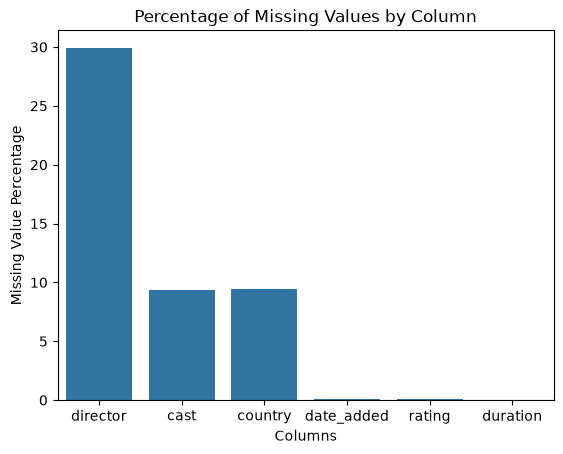

In [12]:
# Vẽ barplot % missing theo cột. Có title và nhãn trục.
# Gợi ý: sns.barplot với missing_df
sns.barplot(x=missing_df.index, y=missing_df['missing_pct'])
plt.title("Percentage of Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Missing Value Percentage")
plt.show()


# Phần 2 — Data Cleaning & Feature Engineering (**3,5 đ**)


### Câu 2.1 — tạo bản sao (**0,2 đ**)

Tạo bản sao từ df, gán vào df_clean.


In [13]:
# Your code here
df_clean = df.copy()

### Câu 2.2 — Cột phân loại đang thiếu (**0,3 đ**)

Kiểu phân loại (Category/Qualitative) có cột nào đang thiếu dữ liệu không?


In [36]:
# Your code here
cot_phan_loai = df.select_dtypes(include=['object', 'category'])
print(cot_phan_loai.isnull().sum())

show_id           0
type              0
title             0
director       2634
cast            825
country         831
date_added       10
rating            4
duration          3
listed_in         0
description       0
dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_1004\2853163656.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cot_phan_loai = df.select_dtypes(include=['object', 'category'])


### Câu 2.3 — Xóa hay impute (**1,0 đ**)

Nếu thiếu:
- Có nên xóa không? Tại sao? Thực thi lệnh.
- Nếu không xóa thì impute dữ liệu gì, tại sao? Thực thi lệnh.


1. Xóa các cột thiếu rất ít
- Tại sao: Các cột date_added, rating, và duration chỉ thiếu từ 3 đến 10 dòng. Nên việc xóa các dòng này trên tổng số hàng ngàn dòng của tập dữ liệu sẽ không làm thay đổi đặc tính phân phối hay làm mất đi các thông tin quan trọng.

In [37]:
df.dropna(subset=['date_added', 'rating', 'type'], inplace=True)

2. Không xóa các cột thiếu nhiều
- Tại sao: Các cột director, cast, country có số lượng thiếu rất lớn. Nếu xóa tất cả các dòng chứa giá trị rỗng ở các cột này, có thể làm mất đi gần 30% dữ liệu gốc, gây hao hụt dữ liệu nghiêm trọng cho các bài phân tích sau.
- Impute dữ liệu gì, tại sao: Impute "Unknown", vì đây là dữ liệu kiểu phân loại mang tính định danh (tên riêng của đạo diễn, diễn viên, hoặc tên quốc gia), không thể điền bằng các phép toán số học trung bình, cũng không thể dùng giá trị xuất hiện nhiều nhất(mode) vì không thể gán bừa tên một đạo diễn cho 2634 bộ phim khác là sai sự thật

In [38]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

### Câu 2.4 — Đổi date_added sang datetime (**0,5 đ**)

Chuyển cột date_added sang datetime.
- Lưu ý: Ép về str, xóa khoảng trắng, ô không parse được dùng NaT (errors="coerce").


In [39]:
df_clean["date_added"] = pd.to_datetime(df_clean["date_added"].astype(str).str.strip(), errors='coerce')

### Câu 2.5 — Kiểm tra date_added sau khi đổi (**0,2 đ**)

In dtype và 5 dòng cột date_added.


In [53]:
# Your code here
print(df_clean.dtypes)
print(df_clean["date_added"].head(5))

show_id                    str
type                       str
title                      str
director                   str
cast                       str
country                    str
date_added      datetime64[us]
release_year             int64
rating                     str
duration                   str
listed_in                  str
description                str
dtype: object
0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[us]


### Câu 2.6 — Tạo year_added, month_added (**0,4 đ**)

Từ date_added, tạo 2 cột mới:
- year_added: năm
- month_added: tên tháng


In [54]:
# Your code here
df_clean['year_added'] = df_clean['date_added'].dt.year
df_clean['month_added'] = df_clean['date_added'].dt.month

### Câu 2.7 — primary_country (**0,4 đ**)

Tạo cột primary_country, lấy quốc gia đầu tiên trong country.
Ví dụ: India, United States -> India


In [56]:
# Your code here
df_clean['primary_country'] = df_clean['country'].str.split(', ', n=1).str[0] 

### Câu 2.8 — primary_genre (**0,3 đ**)

Tạo cột primary_genre, lấy thể loại đầu tiên trong listed_in.
Ví dụ: Dramas, International Movies -> Dramas


In [57]:
# Your code here
df_clean['primary_genre'] = df_clean['listed_in'].str.split(', ', n=1).str[0]

### Câu 2.9 — Tách duration 

Cột duration đang là chữ lẫn số (ví dụ 90 min, 2 Seasons).
Tách làm 2 cột: duration_int (số) và duration_unit (đơn vị).

Gợi ý: str.extract lấy số, str.extract lấy chữ.


In [63]:
# duration_int = phần số (90, 2, ...)
# duration_unit = min / Season / Seasons
# Gợi ý: .str.extract(r"(\d+)") và .str.extract(r"([A-Za-z]+)")
# Your code here
df_clean['duration_int'] = df_clean['duration'].str.extract(r"(\d+)")
df_clean['duration_unit'] = df_clean['duration'].str.extract(r"([A-Za-z]+)")


### Câu 2.10 — Kiểm tra cột mới (**0,1 đ**)

In 5 dòng đầu các cột vừa tạo: type, year_added, primary_country, primary_genre, duration_int, duration_unit.


In [64]:
# Your code here
df_clean[['type', 'year_added', 'primary_country', 'primary_genre', 'duration_int', 'duration_unit']].head(5)

,type,year_added,primary_country,primary_genre,duration_int,duration_unit
0,Movie,2021.0,United States,Documentaries,90,min
1,TV Show,2021.0,South Africa,International TV Shows,2,Seasons
2,TV Show,2021.0,NaN,Crime TV Shows,1,Season
3,TV Show,2021.0,NaN,Docuseries,1,Season
4,TV Show,2021.0,India,International TV Shows,2,Seasons


# Phần 3 — EDA (**3,0 đ**)

## 3.1 Univariate analysis


### Câu 3.1 — Mô tả cột Numeric (**0,2 đ**)

Mô tả các cột Numeric sau khi clean (release_year, year_added, duration_int).


In [65]:
# Your code here
df_clean[['release_year', 'year_added', 'duration_int']].describe()

,release_year,year_added
count,8807.000000,8797.000000
mean,2014.180198,2018.871888
std,8.819312,1.574243
min,1925.000000,2008.000000
25%,2013.000000,2018.000000
50%,2017.000000,2019.000000
75%,2019.000000,2020.000000
max,2021.000000,2021.000000


### Câu 3.2 — Đếm Movie và TV Show (**0,2 đ**)

Đếm số lượng Movie và TV Show. In thêm % mỗi loại, làm tròn 1 chữ số thập phân.


In [81]:
# Your code here
type_count = df_clean['type'].value_counts()
print(type_count)
# Cach 1
print(f"Phần trăm Movies: {(type_count['Movie'] / len(df_clean)) * 100:.1f}%")
print(f"Phần trăm TV Shows: {(type_count['TV Show'] / len(df_clean)) * 100:.1f}%")
# Cach 2
print((df_clean['type'].value_counts(normalize=True) * 100).round(1))

type
Movie      6131
TV Show    2676
Name: count, dtype: int64
Phần trăm Movies: 69.6%
Phần trăm TV Shows: 30.4%
type
Movie      69.6
TV Show    30.4
Name: proportion, dtype: float64


### Câu 3.3 — Barplot type (**0,3 đ**)

Vẽ barplot số lượng Movie và TV Show. Có title, nhãn trục, hiện số trên cột.


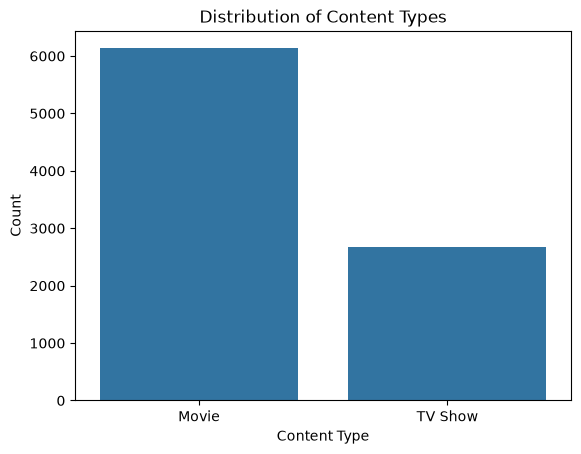

In [82]:
# Dùng type_counts từ câu 3.2 (nếu chưa có thì value_counts lại).
# Your code here
sns.barplot(x=type_count.index, y=type_count.values)
plt.title("Distribution of Content Types")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

### Câu 3.4 — Nhận xét barplot type (**0,2 đ**)

Nhận xét barplot type (2–3 câu, dựa trên số vừa in):
- Loại nào nhiều hơn? Chiếm khoảng bao nhiêu %?
- Catalog Netflix nghiêng phim hay series?


- Nhận xét: Dựa trên biểu đồ và số liệu, thể loại Movie chiếm số lượng nhiều hơn với khoảng 69.6%. Do đó, có thể kết luận rằng catalog Netflix đang nghiêng hẳn về Movie thay vì các Series truyền hình

### Câu 3.5 — Barplot rating (**0,3 đ**)



Content rating là gì?

Content rating = xếp hạng độ tuổi / đối tượng khán giả của phim và TV show trên Netflix.

| Rating | Ý nghĩa |
|---|---|
| TV-MA | Người lớn, nội dung mạnh |
| TV-14 | Từ khoảng 14 tuổi trở lên |
| TV-PG | Trẻ xem được nếu có hướng dẫn phụ huynh |
| PG-13 | Phim điện ảnh, dưới 13 nên có người lớn đi cùng |
| R | Restricted, dưới 17 cần người lớn |
| TV-Y / TV-G | Trẻ nhỏ / mọi lứa tuổi |




Đếm số lượng theo rating, lấy top 12. Vẽ barplot. Có title, nhãn trục.
Làm tương tự barplot type ở trên. Không copy insight có sẵn.

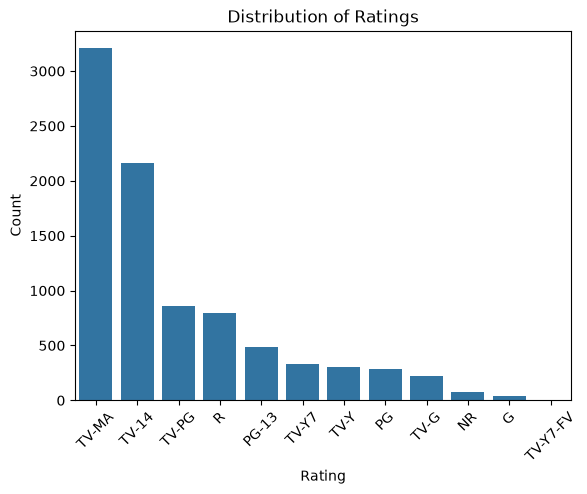

In [89]:
# Your code here
rating_count = df_clean['rating'].value_counts().head(12)
sns.barplot(x=rating_count.index, y=rating_count.values)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Câu 3.6 — Nhận xét barplot rating (**0,2 đ**)

Nhận xét (dựa trên số vừa vẽ):
- Rating nào nhiều nhất? Khoảng bao nhiêu title?
- Catalog nghiêng người lớn, teen, hay trẻ em?


- Nhận xét: Rating xuất hiện nhiều nhất trên Netflix là TV-MA với khoảng hơn 3200 tựa phim và chương trình. Catalog của Netflix nghiêng hẳn về đối tượng Người lớn và Thanh thiếu niên.

### Câu 3.7 — Outlier duration phim (**0,5 đ**)

Cột: duration_int, chỉ các dòng Movie (đơn vị phút). Không dùng TV Show.

Yêu cầu:
1. Boxplot duration phim.
2. Tính IQR: Q1, Q3. 
3. Đếm số điểm ngoài fence.


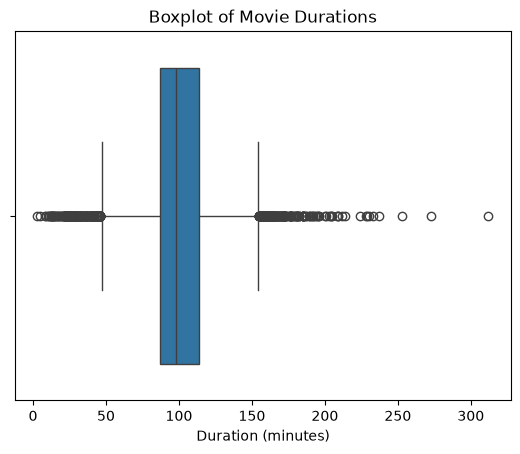

Q1: 87.0, Q3: 114.0, IQR: 27.0
Number of outliers: 450


In [97]:
# lưu ý: Lọc type == Movie, lấy duration_int, bỏ NaN

# Your code here
movie_durations = df_clean[df_clean['type'] == 'Movie']['duration_int'].dropna().astype(int)
sns.boxplot(x=movie_durations)
plt.title("Boxplot of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.show()
Q1 = movie_durations.quantile(0.25)
Q3 = movie_durations.quantile(0.75)
IQR = Q3 - Q1
print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
outliers = movie_durations[(movie_durations < lower_fence) | (movie_durations > upper_fence)]
print(f"Number of outliers: {len(outliers)}")

### Câu 3.8 — Quyết định outlier tiếp câu 3.7 (**0,3 đ**)

Quyết định keep / cap / remove outlier của cột này? Vì sao? 


IQR và clip khác nhau ở điểm nào? (**+0,5 đ**)


In [ ]:
# Your answer here
# Keep / cap / remove: Keep
# Lý do: Các giá trị ngoại lệ của thời lượng phim (rất ngắn hoặc rất dài) phản ánh đúng thực tế của ngành điện ảnh. Đây là dữ liệu thật, không phải lỗi kỹ thuật hay sai sót do nhập liệu. Việc xóa (remove) hoặc ép ngưỡng (cap) sẽ làm sai lệch bản chất của kho nội dung Netflix.



- IQR: Là một phương pháp thống kê toán học dùng để phát hiện và khoanh vùng dữ liệu ngoại lệ. Phương pháp này cung cấp công thức tính ra các ranh giới (cận dưới và trên) để nhận diện dòng dữ liệu nào đang lớn hay nhỏ bất thường.
- Clip: Là một hàm thao tác xử lý dữ liệu dùng để ép/thay thế giá trị. Hàm này sẽ cắt gọt dữ liệu, ép những giá trị vượt quá giới hạn phải quay về đúng bằng mức giới hạn mà người dùng thiết lập (ví dụ: lệnh clip(upper=200) sẽ biến toàn bộ phim dài hơn 200 phút thành đúng 200 phút). 

## 3.2 Multivariate analysis


### Câu 3.9 — Correlation (**0,5 đ**)

Corr các cột release_year, year_added, duration_int.

Gợi ý: duration_int Movie. Nên lọc type == Movie trước khi corr.

Yêu cầu:
1. In ma trận corr.
2. Heatmap, có annot.


              release_year  year_added  duration_int
release_year      1.000000    0.039285     -0.206285
year_added        0.039285    1.000000      0.124436
duration_int     -0.206285    0.124436      1.000000


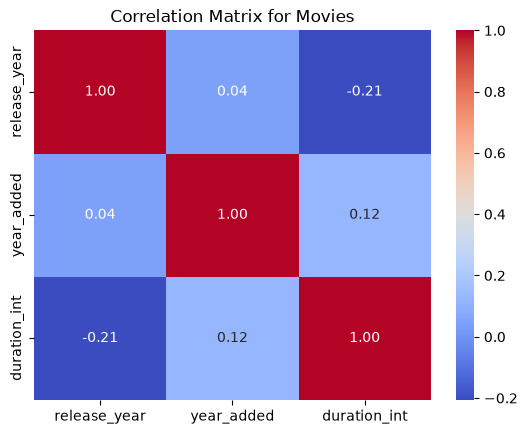

In [99]:
# Your code here
df_movie = df_clean[df_clean['type'] == 'Movie'][['release_year', 'year_added', 'duration_int']]
corr_matrix = df_movie.corr()
print(corr_matrix)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix for Movies")
plt.show()

### Câu 3.10 — Nhận xét corr (**0,3 đ**)

Nhận xét cặp tương quan nổi bật (dương/âm, mạnh/yếu). Ý nghĩa 1 câu.


In [ ]:
# Your answer here
# Mối quan hệ giữa release_year và duration_int có hệ số tương quan là -0.21. Đây là mối tương quan âm nhưng ở mức độ yếu.
# Ý nghĩa: Hệ số âm -0.21 cho thấy một xu hướng nhẹ: Những bộ phim được sản xuất trong các năm gần đây có xu hướng thời lượng ngắn lại đôi chút so với các bộ phim sản xuất ở những thập kỷ trước.


# Phần 4 — Summary và insights (**1,0 đ**)

Điền vào chỗ trống. Lấy số từ output đã chạy. Không bịa số.


### Câu 4.1–4.3

**(1) Chất lượng dữ liệu — 0,3 đ**
Toàn bộ dataset thiếu khoảng ...... %. Cột thiếu nhiều nhất là ...... (khoảng ...... %).
Cột nhóm em fill bằng ...... .

**(2) Catalog — 0,4 đ**
Movie chiếm khoảng ...... %, TV Show khoảng ...... %.
Rating phổ biến nhất: ...... .

**(3) Chọn đúng 1 trong 2 — 0,3 đ**
Outlier: cột duration_int (chỉ Movie, phút) có / không có outlier rõ. Em chọn keep / cap / remove vì ......
hoặc
Tương quan: cặp ...... và ...... có corr khoảng ...... (dương/âm, mạnh/yếu). Ý nghĩa: ......


In [ ]:
# Your answer here
# Toàn bộ dataset thiếu khoảng 4.08 %. Cột thiếu nhiều nhất là director (khoảng 29.91 %). Cột nhóm em fill bằng Unknown .
# Movie chiếm khoảng 69.6 %, TV Show khoảng 30.4 %. Rating phổ biến nhất: TV-MA .
# Outlier: cột duration_int (chỉ Movie, phút) có outlier rõ. Em chọn keep vì rị thời lượng phim rất ngắn hoặc rất dài này phản ánh đúng thực tế của ngành điện ảnh.



# Encoding 


### Câu B1 — Encoding cột type (**+0,7 đ**)

Cột type nên dùng one-hot hay label? Vì sao? Viết code thực thi.


In [100]:
# Your code here
# Lựa chọn: One-hot encoding.
# Lý do: Cột type (gồm "Movie" và "TV Show") là dữ liệu định danh (Nominal), hoàn toàn không có tính thứ bậc. Do đó, One-hot encoding là chuẩn nhất để tránh việc mô hình Machine Learning hiểu nhầm về thứ tự độ lớn.
df_clean = pd.get_dummies(df_clean, columns=['type'], drop_first=True)

### Câu B2 — Encoding rating / primary_genre (**+0,8 đ**)

Cột rating hoặc primary_genre nên dùng loại nào? Vì sao? Viết code thực thi.


In [101]:
# Your code here
# primary_genre
# Lựa chọn: One-hot encoding.
# Lý do: Thể loại phim (Hành động, Hài kịch, Kinh dị...) là dữ liệu định danh (Nominal) và không có tính thứ bậc. Nếu bạn dùng Label encoding (gán số 1, 2, 3...), mô hình sẽ hiểu nhầm sai lệch rằng thể loại số 3 "lớn hơn" thể loại số 1.
df_clean = pd.get_dummies(df_clean, columns=['primary_genre'])